# Credit Card Fraud Detection pomoću neuronskih mreža

**Tema:** Primena neuronskih mreža za predviđanje prevara u finansijama  
**Tip problema:** Binarna klasifikacija ekstremno nebalansiranih podataka  
**Okruženje:** Google Colab + TensorFlow/Keras

U ovom projektu se porede dva pristupa:
1. **Supervised MLP neuronska mreža** za klasifikaciju transakcija.
2. **Autoencoder** kao anomaly detection model koji uči normalne transakcije i prijavljuje neobične transakcije kao sumnjive.

Poenta projekta nije samo da se dobije visoka accuracy, jer kod ovog dataseta model koji sve proglasi regularnim već ima preko 99% tačnosti. Zato gledamo precision, recall, F1, PR-AUC, ROC-AUC i confusion matrix.


## 1. Instalacija i import biblioteka

Notebook je napravljen za Google Colab.  
Dataset se automatski preuzima preko TensorFlow-hosted kopije Kaggle/ULB skupa podataka.

Ako neka biblioteka već postoji u Colab-u, instalacija će se samo preskočiti ili brzo završiti.


In [1]:
# Ova ćelija priprema sve biblioteke koje su potrebne za projekat.
# TensorFlow/Keras koristimo za neuronske mreže, a sklearn za podelu podataka i metrike.
# SEED se koristi da rezultati budu stabilniji između pokretanja.


import sys
!{sys.executable} -m pip install -q --upgrade scikit-learn joblib

import os
import random
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support,
    accuracy_score
)
import joblib

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 71.0 MB/s eta 0:00:00


## 2. Učitavanje podataka

Koristimo poznati **Credit Card Fraud Detection** dataset.

Notebook koristi hybrid pristup:

1. Prvo proverava da li postoji lokalni fajl `data/creditcard.csv`.
2. Ako postoji, učitava lokalni fajl.
3. Ako ne postoji, dataset se automatski preuzima sa TensorFlow-hosted linka, raspakuje i učitava.

Ovo je praktično za Colab i GitHub jer veliki CSV ne mora da bude u repozitorijumu, a projekat se ipak može reprodukovati.


In [2]:
from pathlib import Path
import zipfile
import pandas as pd
from tensorflow import keras

local_csv_candidates = [
    Path("data") / "creditcard.csv",
    Path("../data") / "creditcard.csv",
    Path("/content/data/creditcard.csv"),
]

csv_path = None

for candidate in local_csv_candidates:
    if candidate.exists():
        csv_path = candidate
        print("Dataset pronađen lokalno:", csv_path)
        break

if csv_path is None:
    print("Dataset nije pronađen lokalno. Preuzimam dataset automatski...")

    zip_path = keras.utils.get_file(
        fname="creditcard.zip",
        origin="https://storage.googleapis.com/download.tensorflow.org/data/creditcard.zip",
        extract=False
    )

    zip_path = Path(zip_path)
    extract_dir = zip_path.parent / "creditcard_dataset_extracted"
    extract_dir.mkdir(exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

    csv_candidates = list(extract_dir.rglob("*.csv"))

    if not csv_candidates:
        raise FileNotFoundError("CSV fajl nije pronađen nakon raspakivanja ZIP-a.")

    csv_path = csv_candidates[0]
    print("Dataset automatski preuzet i raspakovan:", csv_path)

df = pd.read_csv(csv_path)

print("Dimenzije dataseta:", df.shape)

df.head()


Dataset nije pronađen lokalno. Preuzimam dataset automatski...
69155632/69155632 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Dataset automatski preuzet i raspakovan: /root/.keras/datasets/creditcard_dataset_extracted/creditcard.csv
Dimenzije dataseta: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Analiza podataka

Najvažnija stvar kod ovog problema je **class imbalance**.  
Prevara ima veoma malo, pa accuracy nije dovoljna metrika.

Na primer, model koji kaže da nijedna transakcija nije prevara ima odličnu accuracy, ali je potpuno beskoristan jer ne detektuje nijednu prevaru.


In [3]:
# Ovde radimo osnovnu proveru dataseta:
# 1. koje kolone postoje,
# 2. da li postoje missing vrednosti,
# 3. koliko ima duplikata,
# 4. koliko ima regularnih transakcija i koliko prevara.

print("Kolone:")
print(df.columns.tolist())

print("\nNedostajuće vrednosti po kolonama:")
print(df.isna().sum().sort_values(ascending=False).head())

print("\nBroj duplikata:", df.duplicated().sum())

class_counts = df["Class"].value_counts().sort_index()
class_percent = df["Class"].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({
    "broj_transakcija": class_counts,
    "procenat": class_percent
})
summary.index = ["Regularna transakcija (0)", "Prevara (1)"]
summary


Kolone:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Nedostajuće vrednosti po kolonama:
Time    0
V1      0
V2      0
V3      0
V4      0
dtype: int64

Broj duplikata: 1081


,broj_transakcija,procenat
Regularna transakcija (0),284315,99.827251
Prevara (1),492,0.172749


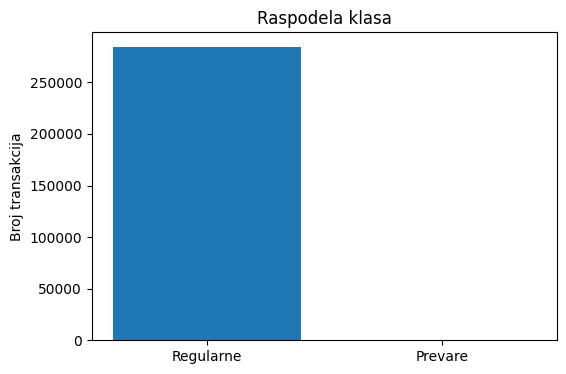

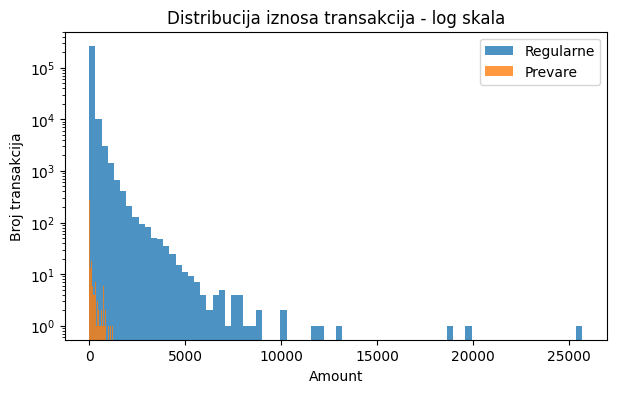

In [4]:
plt.figure(figsize=(6, 4))
plt.bar(["Regularne", "Prevare"], class_counts.values)
plt.title("Raspodela klasa")
plt.ylabel("Broj transakcija")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(df.loc[df["Class"] == 0, "Amount"], bins=80, alpha=0.8, label="Regularne")
plt.hist(df.loc[df["Class"] == 1, "Amount"], bins=80, alpha=0.8, label="Prevare")
plt.yscale("log")
plt.title("Distribucija iznosa transakcija - log skala")
plt.xlabel("Amount")
plt.ylabel("Broj transakcija")
plt.legend()
plt.show()


## 4. Preprocesiranje

Radimo sledeće:

1. Odvajamo `Class` kao ciljnu promenljivu.
2. Delimo podatke na train, validation i test skup.
3. Koristimo stratifikovanu podelu da se odnos regularnih/prevara očuva u svim skupovima.
4. Skaliramo ulazne podatke pomoću `RobustScaler`.
5. Skaler fitujemo samo na trening skupu da ne bi došlo do **data leakage**.

Test skup ostaje realno nebalansiran. To je važno jer u stvarnom sistemu prevare neće činiti 50% transakcija.


In [5]:
features = [c for c in df.columns if c != "Class"]
target = "Class"

X = df[features].copy()
y = df[target].astype(int).copy()

# 60% train, 20% validation, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape, "Fraud rate:", y_train.mean())
print("Validation:", X_val_scaled.shape, "Fraud rate:", y_val.mean())
print("Test:", X_test_scaled.shape, "Fraud rate:", y_test.mean())

n_features = X_train_scaled.shape[1]
n_features


Train: (170884, 30) Fraud rate: 0.0017263172678542169
Validation: (56961, 30) Fraud rate: 0.0017204754130018785
Test: (56962, 30) Fraud rate: 0.0017380007724447878


30

## 5. Pomoćne funkcije za metrike i grafike

Za ovaj problem najbitnije metrike su:

- **Precision**: od svih transakcija koje je model označio kao prevaru, koliko je stvarno prevara.
- **Recall**: od svih stvarnih prevara, koliko ih je model pronašao.
- **F1-score**: balans između precision i recall.
- **PR-AUC**: korisnija metrika od ROC-AUC kod ekstremno nebalansiranih podataka.
- **Confusion matrix**: konkretno pokazuje FP i FN greške.

U praksi:
- **False Negative** je opasan jer prevara prođe neprimećeno.
- **False Positive** je neprijatan jer blokira legitimnog korisnika.


In [6]:
# Ove funkcije nisu model, već pomoćni alat za evaluaciju.
# Posebno je važan threshold, jer model vraća skor/verovatnoću, a mi moramo odlučiti od kog skora transakcija postaje 'prevara'.

def best_threshold_by_f1(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    # thresholds ima jedan element manje od precision/recall.
    precision_for_thr = precision[:-1]
    recall_for_thr = recall[:-1]

    f1_scores = 2 * precision_for_thr * recall_for_thr / (precision_for_thr + recall_for_thr + 1e-12)
    best_idx = int(np.nanargmax(f1_scores))

    return {
        "threshold": float(thresholds[best_idx]),
        "f1": float(f1_scores[best_idx]),
        "precision": float(precision_for_thr[best_idx]),
        "recall": float(recall_for_thr[best_idx])
    }


def evaluate_scores(model_name, y_true, scores, threshold, fn_cost=10, fp_cost=1):
    y_pred = (scores >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )

    accuracy = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, scores)
    pr_auc = average_precision_score(y_true, scores)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    business_cost = fn * fn_cost + fp * fp_cost

    return {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "business_cost": int(business_cost)
    }


def plot_confusion(y_true, scores, threshold, title):
    y_pred = (scores >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0, 1], ["Regular", "Fraud"])
    plt.yticks([0, 1], ["Regular", "Fraud"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.show()


def plot_pr_curve(y_true, scores, title):
    precision, recall, _ = precision_recall_curve(y_true, scores)
    ap = average_precision_score(y_true, scores)

    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision)
    plt.title(f"{title} - PR curve, AP={ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.grid(True)
    plt.show()


def plot_roc_curve(y_true, scores, title):
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc = roc_auc_score(y_true, scores)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"{title} - ROC curve, AUC={auc:.4f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True)
    plt.show()


## 6. Baseline: model koji nikada ne prijavljuje prevaru

Ovaj baseline nam pokazuje zašto accuracy nije dovoljna.  
Ako model sve transakcije proglasi regularnim, imaće vrlo visoku accuracy, ali recall za prevaru biće 0.


In [7]:
zero_scores = np.zeros(len(y_test))
baseline_result = evaluate_scores(
    "Baseline - sve regularno",
    y_test.values,
    zero_scores,
    threshold=0.5
)

pd.DataFrame([baseline_result])


,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,business_cost
0,Baseline - sve regularno,0.5,0.998262,0.0,0.0,0.0,0.5,0.001738,56863,0,99,0,990


## 7. Supervised MLP modeli

MLP je klasična feed-forward neuronska mreža za tabularne podatke.

Koristimo:
- `Dense` slojeve,
- `ReLU` aktivaciju,
- `BatchNormalization`,
- `Dropout`,
- `Adam` optimizator,
- `EarlyStopping` na osnovu validation PR-AUC.

Pored osnovnog MLP modela, testiramo i modele sa `class_weight`.  
`class_weight` daje veću težinu greškama nad fraud klasom, jer je ta klasa retka.


In [8]:
# Ovde definišemo funkciju koja pravi MLP neuronsku mrežu.
# Dense slojevi uče obrasce iz tabularnih podataka.
# Sigmoid izlaz vraća vrednost između 0 i 1, odnosno procenu rizika prevare.

def build_mlp(input_dim, hidden_units=(64, 32), dropout=0.2, learning_rate=1e-3):
    inputs = keras.Input(shape=(input_dim,), name="transaction_features")

    x = inputs
    for i, units in enumerate(hidden_units):
        x = layers.Dense(units, activation="relu", name=f"dense_{i+1}")(x)
        x = layers.BatchNormalization(name=f"batch_norm_{i+1}")(x)
        x = layers.Dropout(dropout, name=f"dropout_{i+1}")(x)

    outputs = layers.Dense(1, activation="sigmoid", name="fraud_probability")(x)

    model = keras.Model(inputs, outputs, name="FraudDetectionMLP")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall")
        ]
    )
    return model


classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train.values)
class_weight = {int(cls): float(w) for cls, w in zip(classes, weights)}

print("Class weights:", class_weight)


Class weights: {0: 0.5008646512963908, 1: 289.63389830508476}


In [9]:
# Ovde treniramo više MLP konfiguracija.
# Razlika između konfiguracija je u broju neurona, dropout-u, learning rate-u i upotrebi class_weight.
# Svaki model se trenira, zatim mu se na validation skupu bira najbolji threshold, a onda se meri rezultat na test skupu.

EPOCHS = 40
BATCH_SIZE = 2048

configs = [
    {
        "name": "MLP_basic_no_class_weight",
        "hidden_units": (64, 32),
        "dropout": 0.2,
        "learning_rate": 1e-3,
        "use_class_weight": False
    },
    {
        "name": "MLP_weighted_64_32",
        "hidden_units": (64, 32),
        "dropout": 0.2,
        "learning_rate": 1e-3,
        "use_class_weight": True
    },
    {
        "name": "MLP_weighted_128_64_dropout",
        "hidden_units": (128, 64),
        "dropout": 0.3,
        "learning_rate": 5e-4,
        "use_class_weight": True
    }
]

trained_models = {}
histories = {}
val_results = []
test_results = [baseline_result]
thresholds = {}

for cfg in configs:
    print("\n" + "=" * 80)
    print("Trening:", cfg["name"])

    model = build_mlp(
        input_dim=n_features,
        hidden_units=cfg["hidden_units"],
        dropout=cfg["dropout"],
        learning_rate=cfg["learning_rate"]
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_pr_auc",
            mode="max",
            patience=5,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        X_train_scaled,
        y_train.values,
        validation_data=(X_val_scaled, y_val.values),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        class_weight=class_weight if cfg["use_class_weight"] else None,
        verbose=1
    )

    val_scores = model.predict(X_val_scaled, batch_size=4096).ravel()
    threshold_info = best_threshold_by_f1(y_val.values, val_scores)
    threshold = threshold_info["threshold"]

    test_scores = model.predict(X_test_scaled, batch_size=4096).ravel()

    val_row = evaluate_scores(
        cfg["name"] + " - validation",
        y_val.values,
        val_scores,
        threshold
    )
    test_row = evaluate_scores(
        cfg["name"] + " - test",
        y_test.values,
        test_scores,
        threshold
    )

    trained_models[cfg["name"]] = model
    histories[cfg["name"]] = history.history
    thresholds[cfg["name"]] = threshold
    val_results.append(val_row)
    test_results.append(test_row)

pd.DataFrame(test_results).sort_values("f1", ascending=False)



Trening: MLP_basic_no_class_weight
Epoch 1/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - loss: 0.6241 - pr_auc: 0.2101 - precision: 0.0049 - recall: 0.8000 - roc_auc: 0.8392 - val_loss: 0.4579 - val_pr_auc: 0.5666 - val_precision: 0.1133 - val_recall: 0.7755 - val_roc_auc: 0.8647
Epoch 2/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.3305 - pr_auc: 0.4101 - precision: 0.0576 - recall: 0.8068 - roc_auc: 0.8839 - val_loss: 0.1960 - val_pr_auc: 0.6016 - val_precision: 0.7684 - val_recall: 0.7449 - val_roc_auc: 0.8425
Epoch 3/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.1415 - pr_auc: 0.4894 - precision: 0.2194 - recall: 0.7661 - roc_auc: 0.8728 - val_loss: 0.0840 - val_pr_auc: 0.5990 - val_precision: 0.7826 - val_recall: 0.7347 - val_roc_auc: 0.8273
Epoch 4/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0661 - pr_auc: 0.5404 - precision: 0.4237 - recall: 0.7153 - roc_auc: 0.8581 - val_loss: 0.0441 - val_pr_auc: 0.5996 - val_precision: 0.7826 - val_recall: 0.7347 - val

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,business_cost
1,MLP_basic_no_class_weight - test,0.161749,0.999403,0.842105,0.808081,0.824742,0.908638,0.834066,56848,15,19,80,205
3,MLP_weighted_128_64_dropout - test,0.999805,0.999315,0.833333,0.757576,0.793651,0.961360,0.740445,56848,15,24,75,255
2,MLP_weighted_64_32 - test,0.989517,0.999052,0.692308,0.818182,0.750000,0.948902,0.716121,56827,36,18,81,216
0,Baseline - sve regularno,0.500000,0.998262,0.000000,0.000000,0.000000,0.500000,0.001738,56863,0,99,0,990


## 8. Krive učenja

Ako validation PR-AUC raste i zatim stagnira, EarlyStopping zaustavlja trening.  
Ako training metrika raste, a validation opada, to je znak overfitting-a.


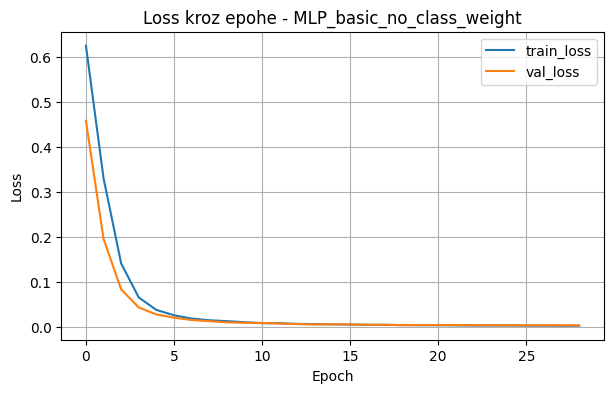

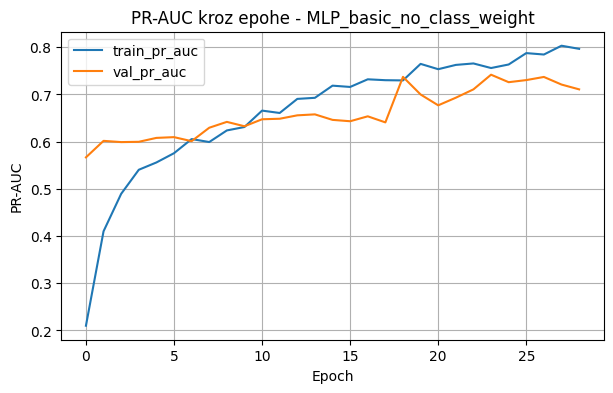

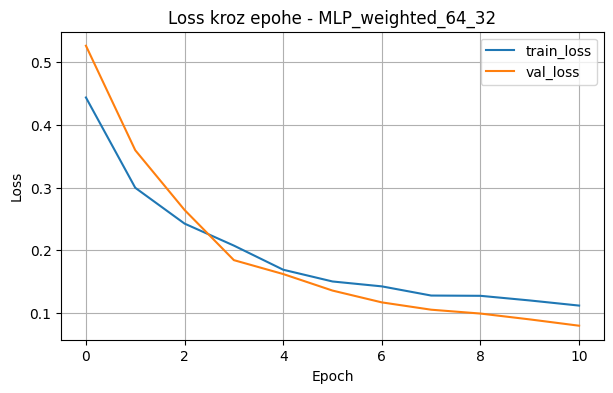

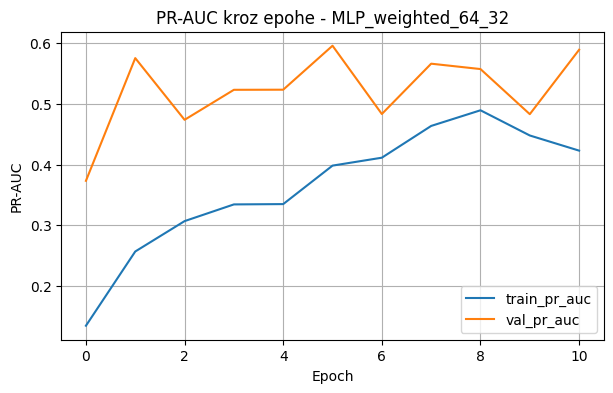

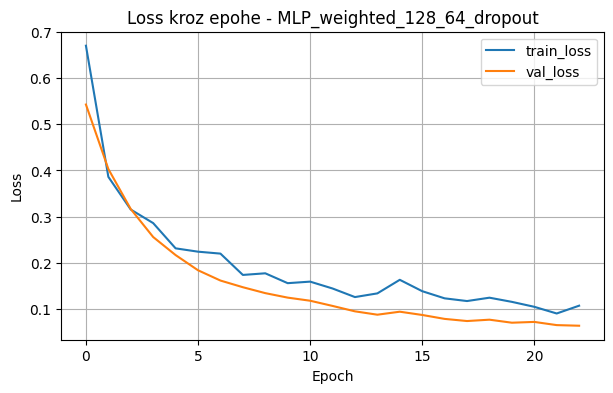

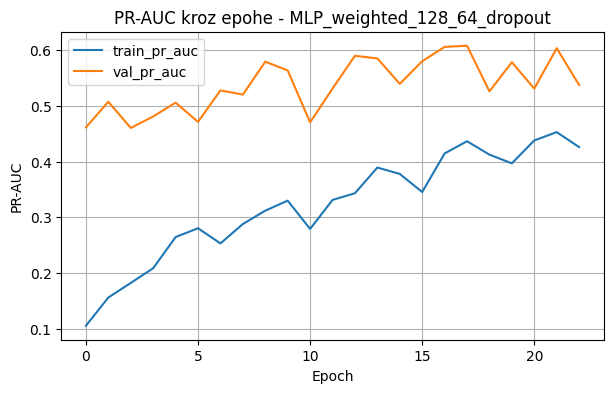

In [10]:
# Ovi grafici prikazuju kako su se loss i PR-AUC menjali kroz epohe.
# Korisni su za proveru da li model uči ili overfituje.

for name, history in histories.items():
    plt.figure(figsize=(7, 4))
    plt.plot(history.get("loss", []), label="train_loss")
    plt.plot(history.get("val_loss", []), label="val_loss")
    plt.title(f"Loss kroz epohe - {name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history.get("pr_auc", []), label="train_pr_auc")
    plt.plot(history.get("val_pr_auc", []), label="val_pr_auc")
    plt.title(f"PR-AUC kroz epohe - {name}")
    plt.xlabel("Epoch")
    plt.ylabel("PR-AUC")
    plt.legend()
    plt.grid(True)
    plt.show()


## 9. Autoencoder kao anomaly detection model

Autoencoder radi drugačije od MLP klasifikatora.

Ideja:
1. Treniramo ga samo na regularnim transakcijama.
2. On uči kako izgleda normalna transakcija.
3. Kada dobije neobičnu transakciju, rekonstrukciona greška je veća.
4. Ako je greška veća od izabranog threshold-a, transakcija se označava kao sumnjiva.

Ovo je dobar dodatak projektu jer pokazuje i polu-nadgledani/anomaly detection pristup, ne samo klasičnu klasifikaciju.


In [11]:
def build_autoencoder(input_dim, encoding_dim=8, learning_rate=1e-3):
    inputs = keras.Input(shape=(input_dim,), name="transaction_features")

    x = layers.Dense(32, activation="relu")(inputs)
    x = layers.Dense(16, activation="relu")(x)
    encoded = layers.Dense(encoding_dim, activation="relu", name="encoded_space")(x)

    x = layers.Dense(16, activation="relu")(encoded)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(input_dim, activation="linear", name="reconstruction")(x)

    autoencoder = keras.Model(inputs, outputs, name="FraudAutoencoder")
    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse"
    )
    return autoencoder


normal_train = X_train_scaled[y_train.values == 0]
normal_val = X_val_scaled[y_val.values == 0]

autoencoder = build_autoencoder(n_features, encoding_dim=8, learning_rate=1e-3)

ae_history = autoencoder.fit(
    normal_train,
    normal_train,
    validation_data=(normal_val, normal_val),
    epochs=50,
    batch_size=2048,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=1
)

def reconstruction_error(model, X_data):
    reconstructed = model.predict(X_data, batch_size=4096)
    return np.mean(np.square(X_data - reconstructed), axis=1)

val_errors = reconstruction_error(autoencoder, X_val_scaled)
ae_threshold_info = best_threshold_by_f1(y_val.values, val_errors)
ae_threshold = ae_threshold_info["threshold"]

test_errors = reconstruction_error(autoencoder, X_test_scaled)
ae_test_result = evaluate_scores(
    "Autoencoder_anomaly_detection - test",
    y_test.values,
    test_errors,
    ae_threshold
)

test_results.append(ae_test_result)

print("Autoencoder threshold info:", ae_threshold_info)
pd.DataFrame([ae_test_result])


Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.7264 - val_loss: 1.4037
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.1737 - val_loss: 1.0637
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8983 - val_loss: 0.8212
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7153 - val_loss: 0.6847
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6419 - val_loss: 0.6369
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5991 - val_loss: 0.5969
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5599 - val_loss: 0.5585
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5224 - val_loss: 0.5192
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.4906 - val_loss: 0.4922
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4679 - val_loss: 0.4716
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4516 - val_loss: 0.4577
Epoch 12/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4391 - val_lo

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,business_cost
0,Autoencoder_anomaly_detection - test,4.176278,0.998367,0.523438,0.676768,0.590308,0.956284,0.601954,56802,61,32,67,381


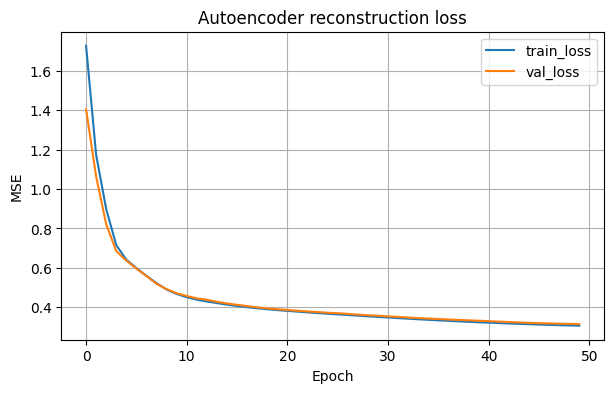

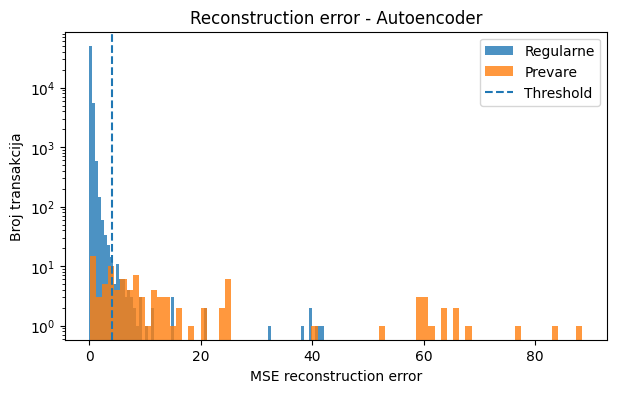

In [12]:
# Ovde analiziramo kako je Autoencoder učio i kakve reconstruction error vrednosti daje.
# Ako su prevare češće na desnoj strani histograma, to znači da ih model vidi kao anomalije.

plt.figure(figsize=(7, 4))
plt.plot(ae_history.history["loss"], label="train_loss")
plt.plot(ae_history.history["val_loss"], label="val_loss")
plt.title("Autoencoder reconstruction loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(test_errors[y_test.values == 0], bins=80, alpha=0.8, label="Regularne")
plt.hist(test_errors[y_test.values == 1], bins=80, alpha=0.8, label="Prevare")
plt.axvline(ae_threshold, linestyle="--", label="Threshold")
plt.yscale("log")
plt.title("Reconstruction error - Autoencoder")
plt.xlabel("MSE reconstruction error")
plt.ylabel("Broj transakcija")
plt.legend()
plt.show()


## 10. Finalna evaluacija modela

Threshold se bira na validation skupu, a finalna ocena se radi na test skupu.  
To je bitno jer test skup ne sme da utiče na izbor modela ili threshold-a.

U tabeli gledamo:
- F1 kao balans precision/recall,
- Recall ako nam je važnije da uhvatimo što više prevara,
- Precision ako nam je važnije da smanjimo lažne uzbune,
- Business cost kao pojednostavljenu poslovnu cenu grešaka.


In [13]:
# Ova tabela je finalno poređenje svih modela.
# Najviše obrati pažnju na F1, recall, precision i PR-AUC.
# Accuracy je prikazana, ali nije glavna metrika za ovaj problem.

results_df = pd.DataFrame(test_results).drop_duplicates(subset=["model"], keep="last")
results_df = results_df.sort_values(["f1", "pr_auc"], ascending=False).reset_index(drop=True)
results_df


,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,business_cost
0,MLP_basic_no_class_weight - test,0.161749,0.999403,0.842105,0.808081,0.824742,0.908638,0.834066,56848,15,19,80,205
1,MLP_weighted_128_64_dropout - test,0.999805,0.999315,0.833333,0.757576,0.793651,0.961360,0.740445,56848,15,24,75,255
2,MLP_weighted_64_32 - test,0.989517,0.999052,0.692308,0.818182,0.750000,0.948902,0.716121,56827,36,18,81,216
3,Autoencoder_anomaly_detection - test,4.176278,0.998367,0.523438,0.676768,0.590308,0.956284,0.601954,56802,61,32,67,381
4,Baseline - sve regularno,0.500000,0.998262,0.000000,0.000000,0.000000,0.500000,0.001738,56863,0,99,0,990


Najbolji supervised model na test skupu: MLP_basic_no_class_weight
F1-score: 0.8247422680412371
PR-AUC: 0.8340659894612048
Threshold izabran na validation skupu: 0.16174940764904022
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


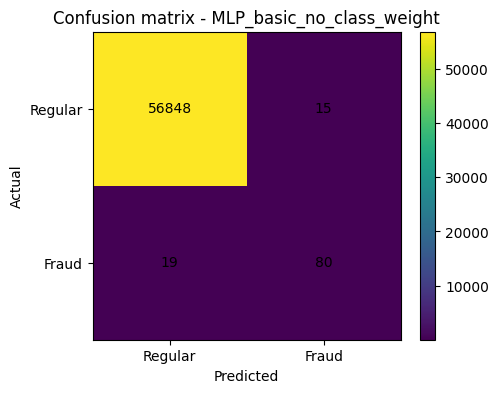

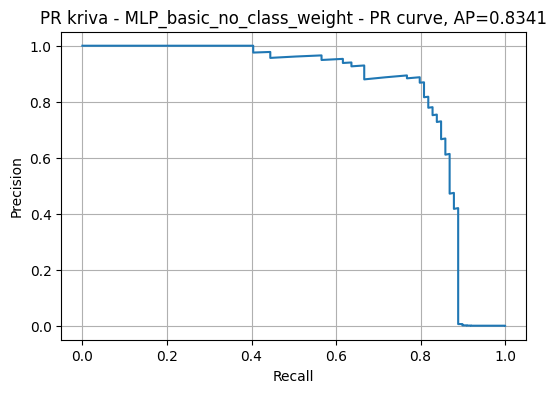

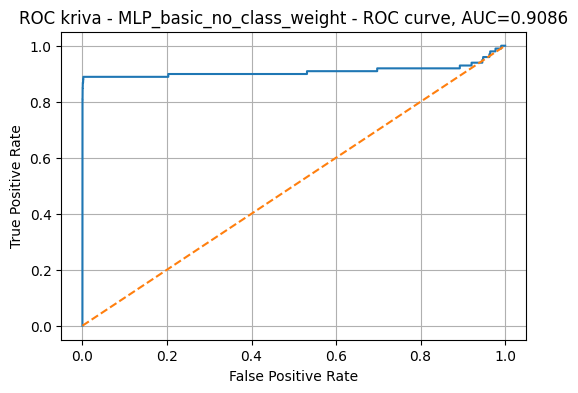

              precision    recall  f1-score   support

   Regularna       1.00      1.00      1.00     56863
     Prevara       0.84      0.81      0.82        99

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [14]:
# Ovde uzimamo najbolji supervised model na finalnom test skupu
# i detaljnije ga prikazujemo kroz confusion matrix, PR krivu i ROC krivu.
# Threshold je i dalje izabran na validation skupu, ali najbolji model biramo po test rezultatima.

supervised_test_df = results_df[
    results_df["model"].str.contains("MLP", regex=False)
].copy()

best_test_row = supervised_test_df.sort_values(
    ["f1", "pr_auc"],
    ascending=False
).iloc[0]

best_supervised_name = best_test_row["model"].replace(" - test", "")

print("Najbolji supervised model na test skupu:", best_supervised_name)
print("F1-score:", best_test_row["f1"])
print("PR-AUC:", best_test_row["pr_auc"])

best_model = trained_models[best_supervised_name]
best_threshold = thresholds[best_supervised_name]

print("Threshold izabran na validation skupu:", best_threshold)

best_test_scores = best_model.predict(X_test_scaled, batch_size=4096).ravel()
best_test_preds = (best_test_scores >= best_threshold).astype(int)

plot_confusion(
    y_test.values,
    best_test_scores,
    best_threshold,
    f"Confusion matrix - {best_supervised_name}"
)

plot_pr_curve(
    y_test.values,
    best_test_scores,
    f"PR kriva - {best_supervised_name}"
)

plot_roc_curve(
    y_test.values,
    best_test_scores,
    f"ROC kriva - {best_supervised_name}"
)

print(classification_report(
    y_test.values,
    best_test_preds,
    target_names=["Regularna", "Prevara"],
    zero_division=0
))


## 11. Threshold analiza

Klasifikaciona neuronska mreža vraća verovatnoću/rizik, a ne direktnu odluku.  
Threshold određuje od kog rizika kažemo: "ovo je prevara".

- Niži threshold: više transakcija se označava kao prevara → veći recall, više false positive grešaka.
- Viši threshold: model je stroži → manje false positive grešaka, ali može propustiti više prevara.

Zato threshold nije samo tehničko pitanje, nego poslovna odluka.


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


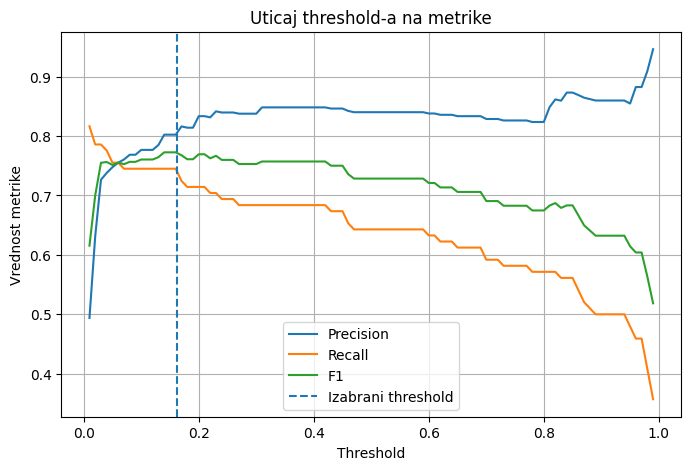

,threshold,precision,recall,f1,business_cost
14,0.15,0.802198,0.744898,0.772487,268
15,0.16,0.802198,0.744898,0.772487,268
13,0.14,0.802198,0.744898,0.772487,268
20,0.21,0.833333,0.714286,0.769231,294
19,0.20,0.833333,0.714286,0.769231,294
16,0.17,0.816092,0.724490,0.767568,286
22,0.23,0.841463,0.704082,0.766667,303
12,0.13,0.784946,0.744898,0.764398,270
21,0.22,0.831325,0.704082,0.762431,304
18,0.19,0.813953,0.714286,0.760870,296


In [15]:
val_scores_best = best_model.predict(X_val_scaled, batch_size=4096).ravel()

threshold_grid = np.linspace(0.01, 0.99, 99)
threshold_rows = []

for thr in threshold_grid:
    row = evaluate_scores(
        f"threshold_{thr:.2f}",
        y_val.values,
        val_scores_best,
        thr
    )
    threshold_rows.append({
        "threshold": thr,
        "precision": row["precision"],
        "recall": row["recall"],
        "f1": row["f1"],
        "business_cost": row["business_cost"]
    })

threshold_df = pd.DataFrame(threshold_rows)

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(best_threshold, linestyle="--", label="Izabrani threshold")
plt.title("Uticaj threshold-a na metrike")
plt.xlabel("Threshold")
plt.ylabel("Vrednost metrike")
plt.legend()
plt.grid(True)
plt.show()

threshold_df.sort_values("f1", ascending=False).head(10)


## 12. Analiza osetljivosti: permutation importance

Pošto su `V1`–`V28` PCA kolone, ne znamo njihovo originalno značenje.  
Ipak možemo proveriti koje kolone model najviše koristi.

Permutation importance radi ovako:
1. Izračuna se osnovni PR-AUC.
2. Jedna kolona se nasumično izmeša.
3. Ako metrika značajno padne, znači da je ta kolona važna za model.

Ovo nije savršeno objašnjenje neuronske mreže, ali je dovoljno intuitivno za seminarski projekat.


In [16]:
# Da bi bilo brzo, koristi se subset validation skupa.
sample_size = min(15000, len(X_val_scaled))
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_val_scaled), size=sample_size, replace=False)

X_sample = X_val_scaled[sample_idx].copy()
y_sample = y_val.values[sample_idx].copy()

base_scores = best_model.predict(X_sample, batch_size=4096).ravel()
base_ap = average_precision_score(y_sample, base_scores)

importance_rows = []

for col_idx, col_name in enumerate(features):
    X_permuted = X_sample.copy()
    rng.shuffle(X_permuted[:, col_idx])

    permuted_scores = best_model.predict(X_permuted, batch_size=4096).ravel()
    permuted_ap = average_precision_score(y_sample, permuted_scores)

    importance_rows.append({
        "feature": col_name,
        "base_pr_auc": base_ap,
        "permuted_pr_auc": permuted_ap,
        "importance_drop": base_ap - permuted_ap
    })

importance_df = pd.DataFrame(importance_rows).sort_values("importance_drop", ascending=False)
importance_df.head(15)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━

,feature,base_pr_auc,permuted_pr_auc,importance_drop
14,V14,0.891293,0.512396,0.378897
27,V27,0.891293,0.826532,0.064761
17,V17,0.891293,0.854536,0.036757
10,V10,0.891293,0.864640,0.026654
12,V12,0.891293,0.864700,0.026593
4,V4,0.891293,0.872339,0.018954
8,V8,0.891293,0.877894,0.013400
28,V28,0.891293,0.879588,0.011705
29,Amount,0.891293,0.883540,0.007753
20,V20,0.891293,0.885532,0.005761


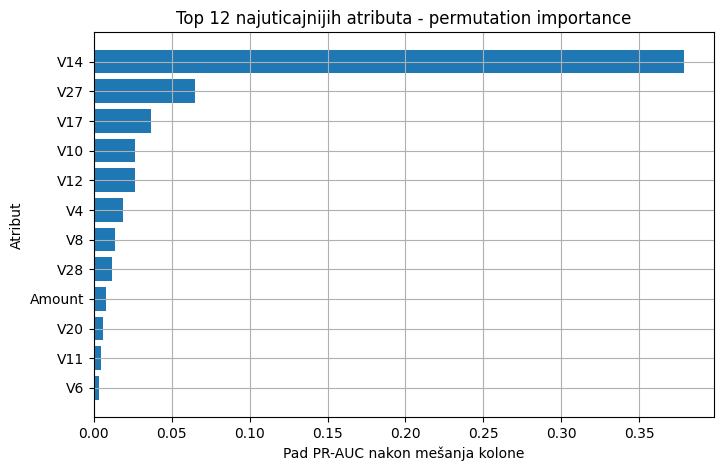

In [17]:
top_imp = importance_df.head(12).sort_values("importance_drop")

plt.figure(figsize=(8, 5))
plt.barh(top_imp["feature"], top_imp["importance_drop"])
plt.title("Top 12 najuticajnijih atributa - permutation importance")
plt.xlabel("Pad PR-AUC nakon mešanja kolone")
plt.ylabel("Atribut")
plt.grid(True)
plt.show()


## 13. Čuvanje rezultata i modela

Ova ćelija čuva:
- tabelu metrika,
- najbolji supervised model,
- autoencoder model,
- scaler.

In [18]:
# Na kraju čuvamo rezultate, modele i scaler.
# Scaler je važan jer svaki novi podatak mora da prođe istu transformaciju kao trening podaci.

outputs_dir = Path("outputs")
outputs_dir.mkdir(exist_ok=True)

results_df.to_csv(outputs_dir / "model_comparison.csv", index=False)
importance_df.to_csv(outputs_dir / "permutation_importance.csv", index=False)

best_model.save(outputs_dir / "best_supervised_mlp.keras")
autoencoder.save(outputs_dir / "autoencoder.keras")
joblib.dump(scaler, outputs_dir / "robust_scaler.joblib")

print("Sačuvani fajlovi:")
for path in outputs_dir.iterdir():
    print("-", path)


Sačuvani fajlovi:
- outputs/model_comparison.csv
- outputs/autoencoder.keras
- outputs/best_supervised_mlp.keras
- outputs/robust_scaler.joblib
- outputs/permutation_importance.csv


## 14. Zaključak

U ovom projektu je prikazana detekcija prevara sa kreditnim karticama pomoću neuronskih mreža.

Najvažniji zaključci:

1. Problem je ekstremno nebalansiran, pa accuracy nije dovoljna metrika.
2. Supervised MLP može dobro da nauči obrasce prevare, ali threshold mora pažljivo da se bira.
3. `class_weight` pomaže modelu da više obraća pažnju na retku fraud klasu, ali može povećati broj lažnih uzbuna.
4. Autoencoder je koristan kao anomaly detection pristup jer uči normalno ponašanje i prijavljuje odstupanja.
5. Najbolji model se ne bira samo po accuracy, nego po odnosu precision/recall/F1 i po poslovnom kompromisu između false positive i false negative grešaka.


## 15. Primer korišćenja modela nad jednom transakcijom

Ovo je samo demonstracija kako bi se model koristio nakon treninga.  
U realnom sistemu bi backend dobio podatke o transakciji, skalirao ih istim scaler-om i poslao modelu.


In [19]:
def predict_fraud_for_row(raw_row, scaler, model, threshold, feature_names):
    row_df = pd.DataFrame([raw_row])[feature_names]
    row_scaled = scaler.transform(row_df)
    risk_score = float(model.predict(row_scaled, verbose=0).ravel()[0])
    predicted_class = int(risk_score >= threshold)

    return {
        "risk_score": risk_score,
        "threshold": threshold,
        "predicted_class": predicted_class,
        "label": "Prevara" if predicted_class == 1 else "Regularna transakcija"
    }

# Primer: uzimamo jednu transakciju iz test skupa.
example_row = X_test.iloc[0].to_dict()
predict_fraud_for_row(example_row, scaler, best_model, best_threshold, features)


{'risk_score': 0.0006746725994162261,
 'threshold': 0.16174940764904022,
 'predicted_class': 0,
 'label': 'Regularna transakcija'}